### `The Target is (medina_house_value), and Evaluation Metric is (RMSE)`


In [28]:
## Major Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns

## Other
import os, joblib

## sklearn -- Preprocessing & Tuning & Transformation
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler,LabelEncoder,OneHotEncoder,PolynomialFeatures,)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer

## sklearn -- metrics
from sklearn.metrics import root_mean_squared_error, r2_score

## sklearn -- Models
from sklearn.linear_model import (LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet,)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

## Xgboost
from xgboost import XGBRegressor

### `Load the Dataset and Look at the big Picture`

In [2]:
## Read the CSV file using pandas
FILE_PATH = os.path.join(os.getcwd(), '..' , 'Data' ,"housing.csv")
df_housing = pd.read_csv(FILE_PATH)


## Show the Head of the DF
df_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
## Check some info about the Dataset to (see nulls and DataTypes)
df_housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [4]:
## Show some statistics about the Dataset
df_housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
## Check the nulls
df_housing.isna().sum()  ## axis=0 -- by defualt

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

* > `Comment: It seems that Dataset is a contains 20640 instances and only 207 null values in total_bedrooms feature, and also all datatypes is float64 as they are continuous numerical features except the (ocean_proximity) column which is nominal categorical Feature` 

### `Exploratory Data Analysis`

### `Univariate Visualization`

Text(0, 0.5, 'Counts')

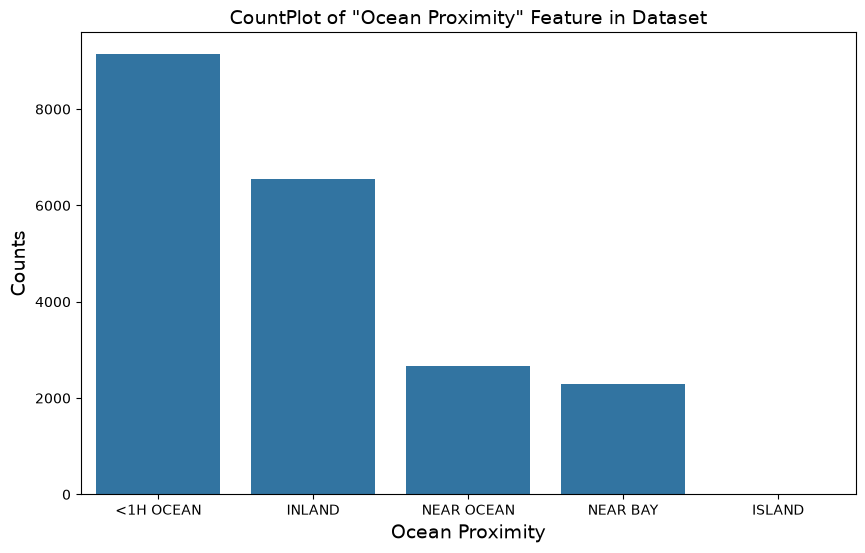

In [6]:
### Check the Distribution of (ocean_proximity) Feature in Dataset
ocean_values = df_housing["ocean_proximity"].value_counts()


## Plotting
plt.figure(figsize=(10, 6))
sns.countplot(x="ocean_proximity", data=df_housing, order=ocean_values.index)
plt.title('CountPlot of "Ocean Proximity" Feature in Dataset', fontsize=14, c="k")
plt.xlabel("Ocean Proximity", fontsize=14, c="k")
plt.ylabel("Counts", fontsize=14, c="k")

In [7]:
## Replace the  (<1H OCEAN) to (1H OCEAN) -- will cause ane errors in Deploymnet
df_housing["ocean_proximity"] = df_housing["ocean_proximity"].replace(
    "<1H OCEAN", "1H OCEAN"
)

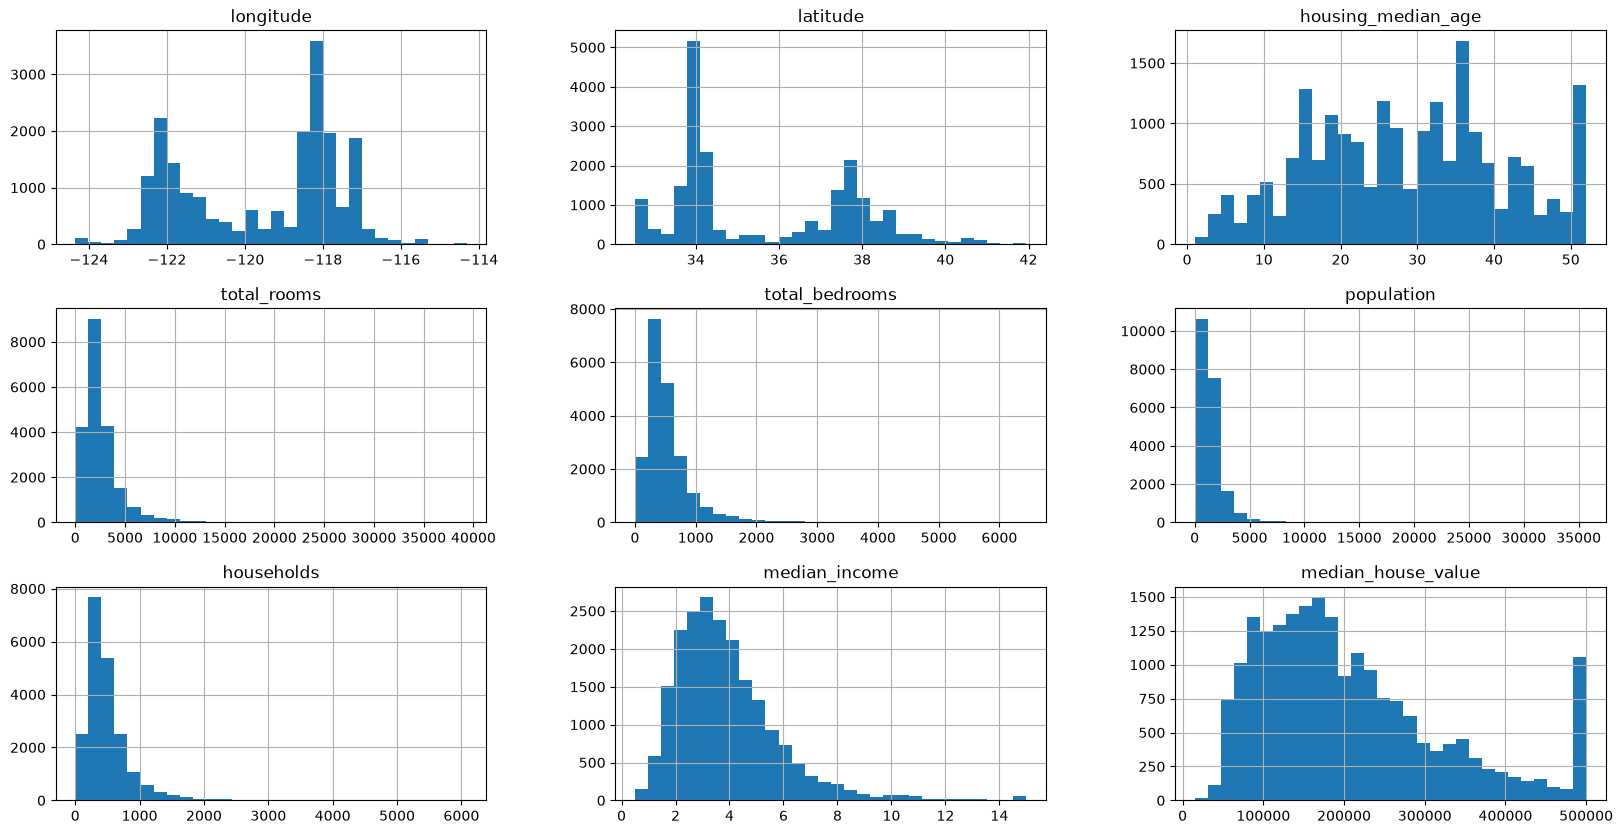

In [8]:
## Histogram Distr. of Numerical Features in Dataset
df_housing.hist(bins=30, figsize=(20, 10))
plt.show()

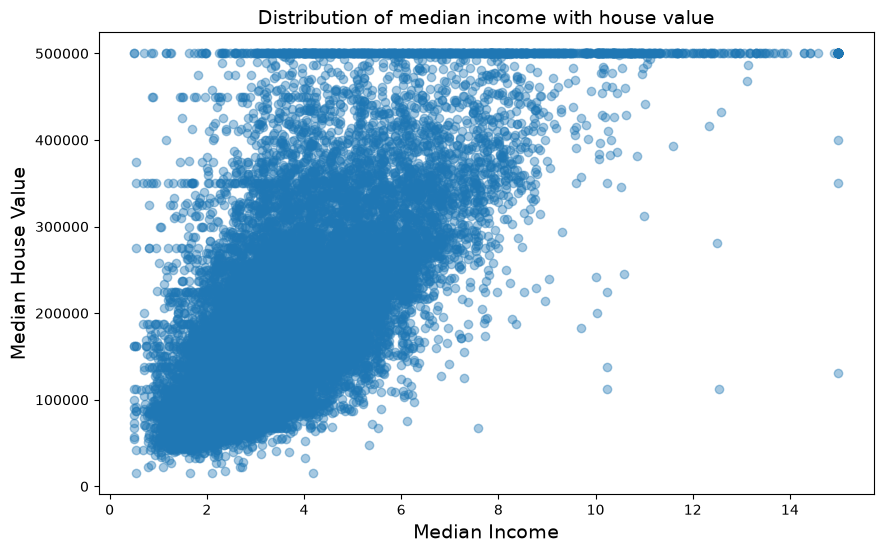

In [9]:
## Scatterplot with important Feature (medina_income) with the target (median_house_value)
plt.figure(figsize=(10, 6))
plt.scatter(df_housing["median_income"], df_housing["median_house_value"], alpha=0.4)
plt.title("Distribution of median income with house value", fontsize=14, c="k")
plt.xlabel("Median Income", fontsize=14, c="k")
plt.ylabel("Median House Value", fontsize=14, c="k")
plt.show()

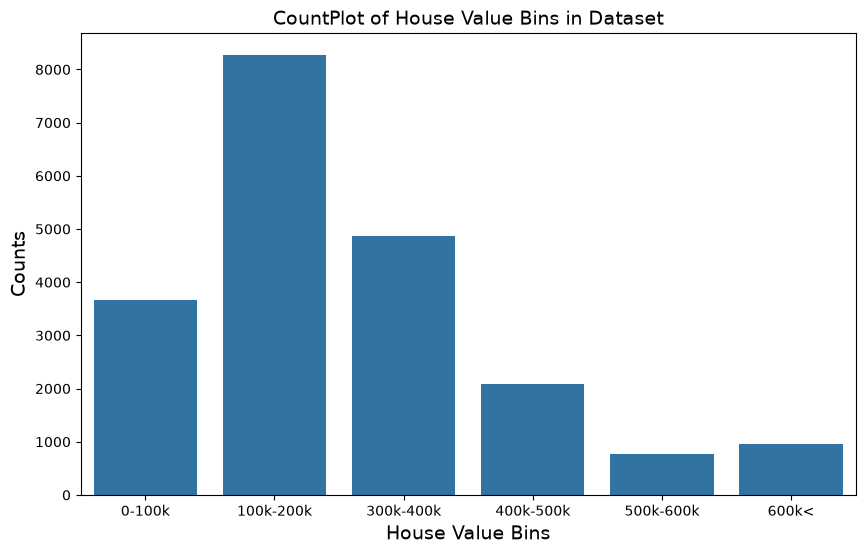

In [10]:
## Try for (median_house_value) to convert it into chunks (bins)
## Cut this Numerical Feature to Categorical One
## Ex: for the following example -- any value between range (0-100k) will be the same category (like histogram)

house_value_bins = pd.cut(
    x=df_housing["median_house_value"],
    bins=[-np.inf, 100000, 200000, 300000, 400000, 500000, np.inf],
    labels=["0-100k", "100k-200k", "300k-400k", "400k-500k", "500k-600k", "600k<"],
)


## Countplot for the above chunks
plt.figure(figsize=(10, 6))
sns.countplot(x=house_value_bins)
plt.title("CountPlot of House Value Bins in Dataset", fontsize=14, c="k")
plt.xlabel("House Value Bins", fontsize=14, c="k")
plt.ylabel("Counts", fontsize=14, c="k")
plt.show()

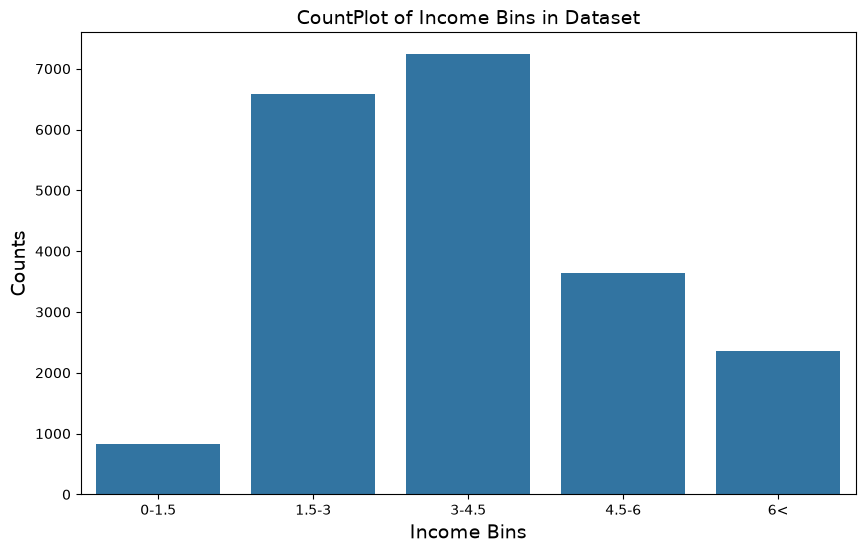

In [11]:
## Let's try the same above code for (median_income), I think it is very important Feature
income_bins = pd.cut(
    x=df_housing["median_income"],
    bins=[-np.inf, 1.5, 3, 4.5, 6, np.inf],
    labels=["0-1.5", "1.5-3", "3-4.5", "4.5-6", "6<"],
)


## Countplot for the above chunks
plt.figure(figsize=(10, 6))
sns.countplot(x=income_bins)
plt.title("CountPlot of Income Bins in Dataset", fontsize=14, c="k")
plt.xlabel("Income Bins", fontsize=14, c="k")
plt.ylabel("Counts", fontsize=14, c="k")
plt.show()

### `Bivariate Visualization`

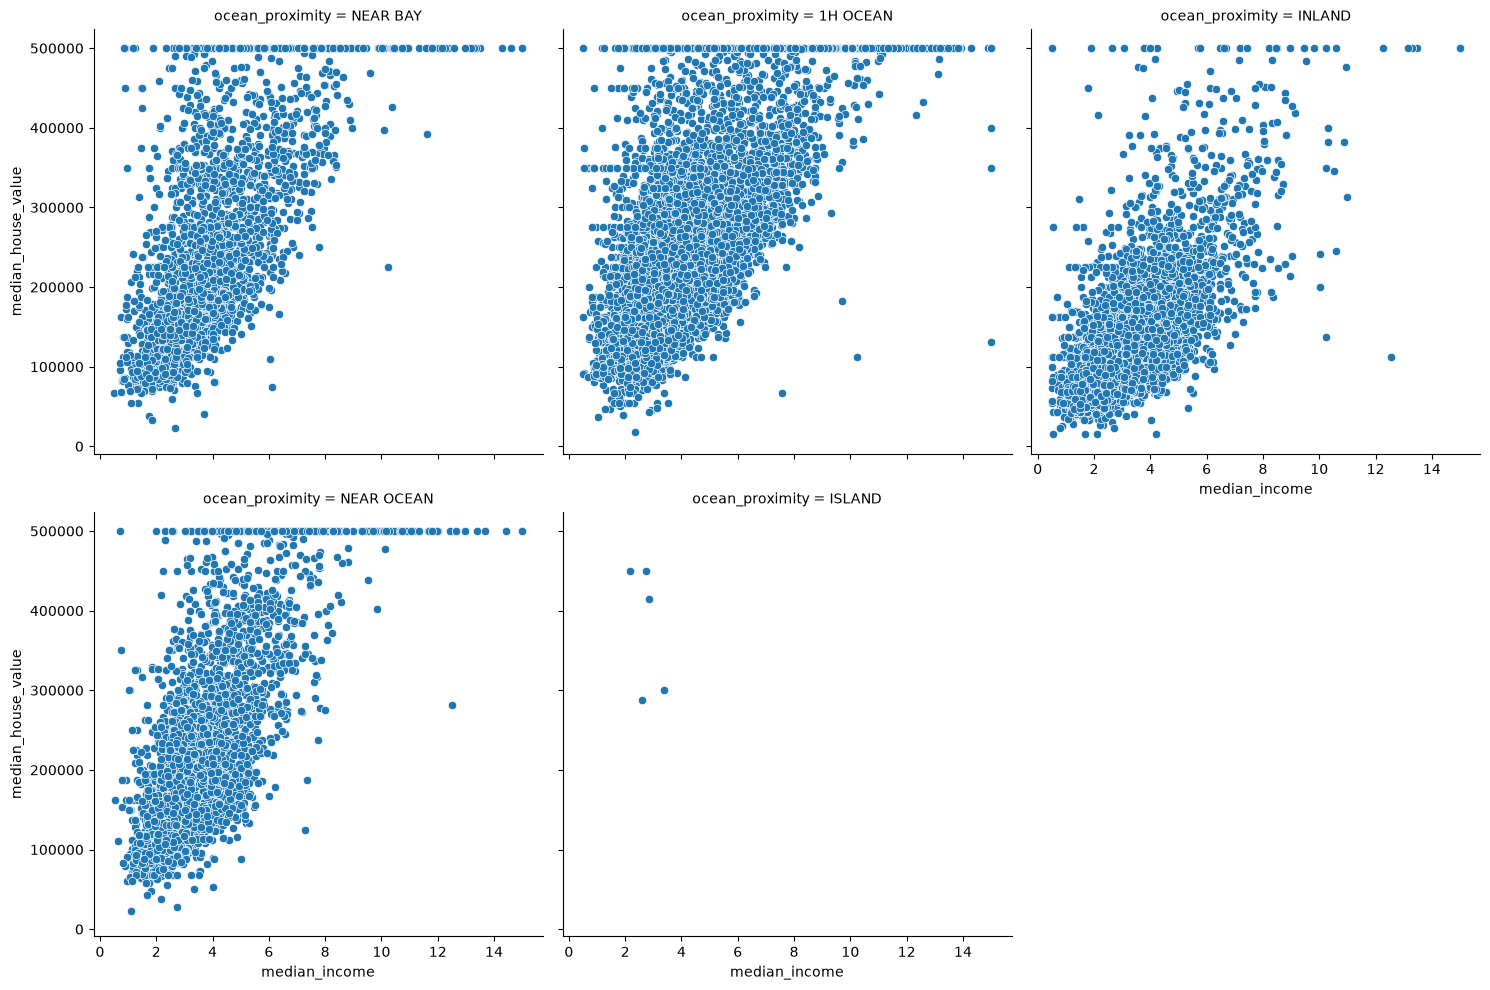

In [12]:
## Scatterplot with (median_income) & (median_house_value) at each (ocean_proximity)
sns.relplot(
    x="median_income",
    y="median_house_value",
    data=df_housing,
    kind="scatter",
    col="ocean_proximity",
    col_wrap=3,
)
plt.show()

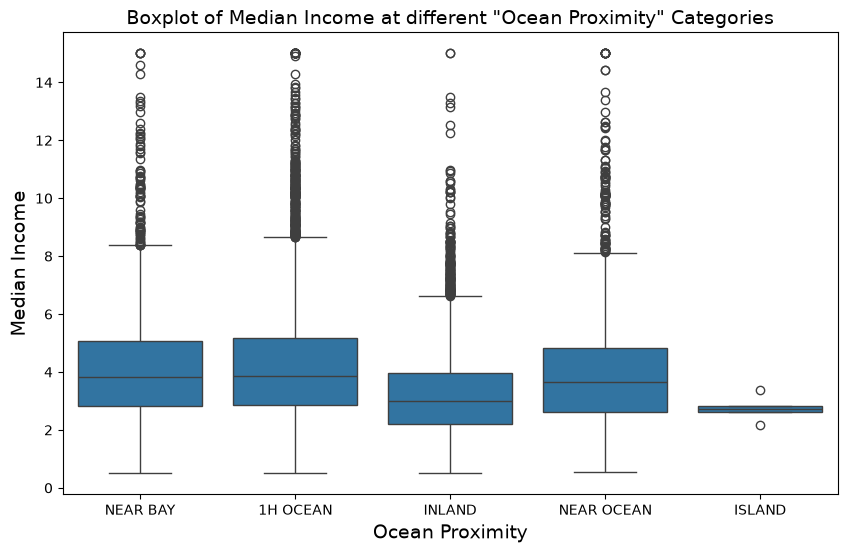

In [13]:
## Check the BoxPlot of the (median_income) at different Categories of (ocean_proximity)
plt.figure(figsize=(10, 6))
sns.boxplot(y="median_income", data=df_housing, x="ocean_proximity")
plt.title(
    'Boxplot of Median Income at different "Ocean Proximity" Categories',
    fontsize=14,
    c="k",
)
plt.xlabel("Ocean Proximity", fontsize=14, c="k")
plt.ylabel("Median Income", fontsize=14, c="k")
plt.show()

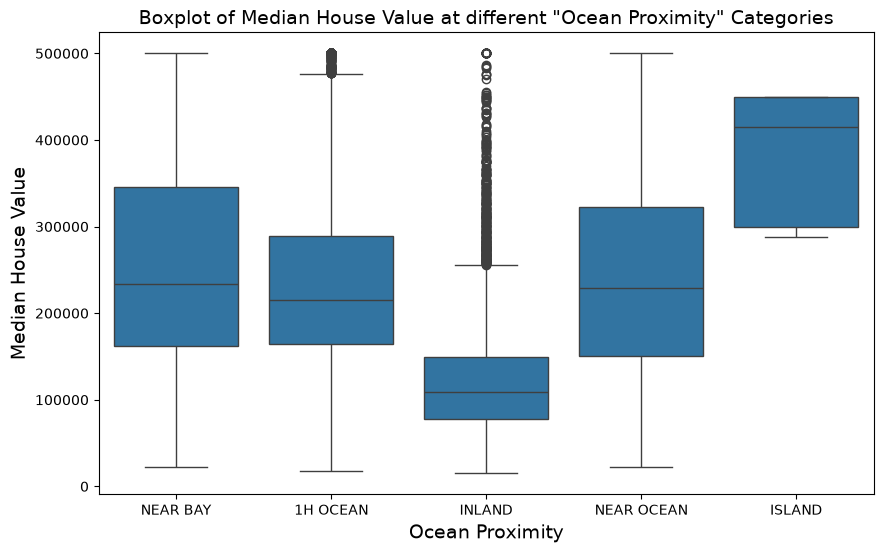

In [14]:
## Check the BoxPlot for (median_house_value) at different Categories of (ocean_proximity)
plt.figure(figsize=(10, 6))
sns.boxplot(y="median_house_value", data=df_housing, x="ocean_proximity")
plt.title(
    'Boxplot of Median House Value at different "Ocean Proximity" Categories',
    fontsize=14,
    c="k",
)
plt.xlabel("Ocean Proximity", fontsize=14, c="k")
plt.ylabel("Median House Value", fontsize=14, c="k")
plt.show()

* > `Comment: It seems that the Distribution of median_income is almost the same at ocean_proximity categories, Also, it seems that the INLAND median_income and median_house value is less than other categories and it makes sense ` 

### `Multivariate Visualization`

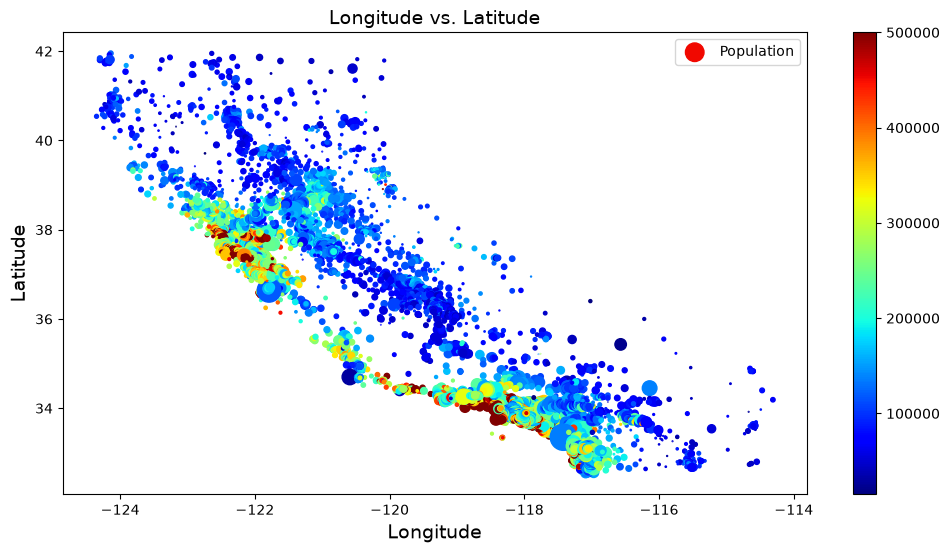

In [15]:
## ScatterPlot for (longitude & Latitude), and add (population) as size of point, and the color as (median_house_value)
plt.figure(figsize=(12, 6))
sc = plt.scatter(
    x=df_housing["longitude"],
    y=df_housing["latitude"],
    s=df_housing["population"] / 100,
    c=df_housing["median_house_value"],
    cmap=plt.get_cmap("jet"),
    label="Population",
)
plt.colorbar(sc)  ## colorbar
plt.xlabel("Longitude", fontsize=14, c="k")
plt.ylabel("Latitude", fontsize=14, c="k")
plt.title("Longitude vs. Latitude", fontsize=14, c="k")
plt.legend()
plt.show()

* > `Comment: It seems that prices is higher near the ocean than other zones, and also these araes have higher population` 

### `Check the Correlation between the Features and Target`

In [16]:
## Using pearson correlation
df_housing.corr(numeric_only= True)["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

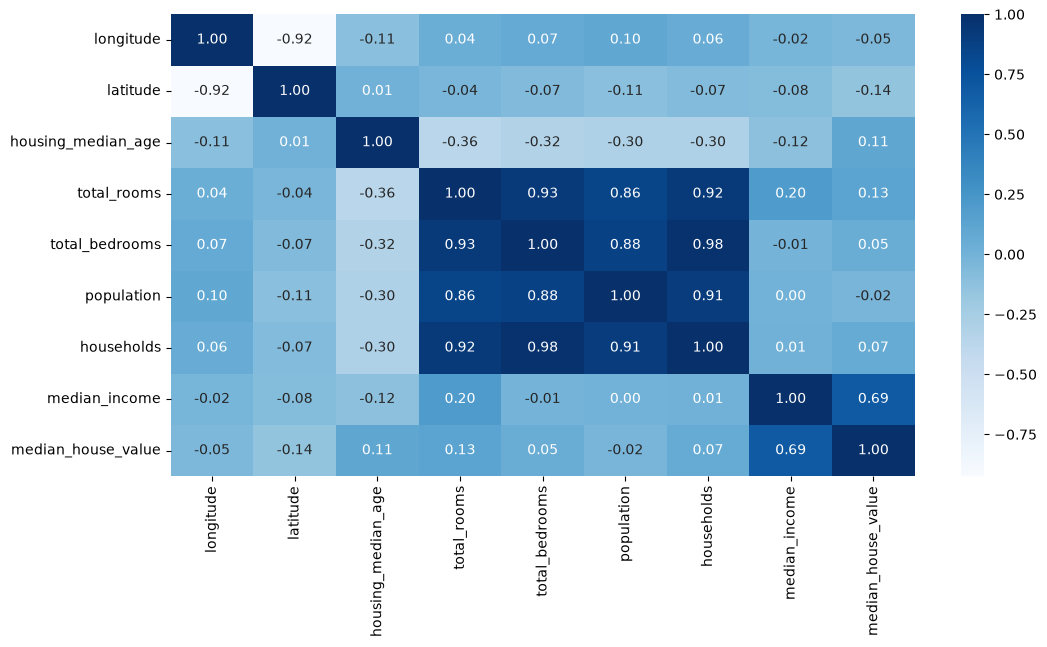

In [17]:
## you can show this as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_housing.corr(numeric_only= True), annot=True, cmap="Blues", fmt=".2f")  ## symmetric matrix
plt.show()

* > `Comment: It seems that the most correlated Feature with target is (median_income) as I predict that, and feature like (households & population) are less correlated` 

### `Feature Engineering`

In [18]:
## Try to make some Feature Engineering --> Feature Extraction --> Add the new column to the main DF
df_housing["rooms_per_household"] = df_housing["total_rooms"] / df_housing["households"]
df_housing["bedroms_per_rooms"] = (
    df_housing["total_bedrooms"] / df_housing["total_rooms"]
)
df_housing["population_per_household"] = (
    df_housing["population"] / df_housing["households"]
)

In [19]:
## check the correlation again
df_housing.corr(numeric_only= True)["median_house_value"].sort_values(
    ascending=False
)  ## some progress for out new features (very good)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedroms_per_rooms          -0.255880
Name: median_house_value, dtype: float64

* > `Comment:Some progress for out new features (very good), Strong correlation` 

### `Split the Dataset`
``I will split the Dataset using ordinary method (random method) not (Stratified method)``

In [20]:
## Split the whole Dataset to Feature & Target
X = df_housing.drop(columns=["median_house_value"])  ## Features
y = df_housing["median_house_value"]  ## target

In [21]:
## Random split the dataset to two sets (train_set, test_set)
## For validation ---  I will use Cross Validation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, shuffle=True, random_state=42
)


## Check Shapes of these Sets
print("X_train shape -- ", X_train.shape)
print("y_train shape -- ", y_train.shape)
print("X_test shape -- ", X_test.shape)
print("y_test shape -- ", y_test.shape)

X_train shape --  (17544, 12)
y_train shape --  (17544,)
X_test shape --  (3096, 12)
y_test shape --  (3096,)


* > ## `Total Pipline`
``Dealing with nulls``
``Standardize the Features``
``Encoding`` 

In [22]:
## Separete the columns according to type (numerical or categorical)
num_cols = [
    col
    for col in X_train.columns
    if X_train[col].dtype in ["float32", "float64", "int32", "int64"]
]
categ_cols = [
    col
    for col in X_train.columns
    if X_train[col].dtype not in ["float32", "float64", "int32", "int64"]
]

In [23]:
## We can get much much easier like the following
## numerical pipeline
num_pipeline = Pipeline(
    [ 
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

## categorical pipeline
categ_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("OHE", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", num_pipeline, num_cols),
        ("categorical", categ_pipeline, categ_cols),
                ]
)

## deal with (total_pipeline) as an instance -- fit and transform to train dataset and transform only to other datasets
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)  ### Every thing is processed :D

In [24]:
MODEL_FOLDER_PATH = os.path.join(os.getcwd(),'..','models')
os.makedirs(MODEL_FOLDER_PATH, exist_ok=True)

In [25]:
joblib.dump(preprocessor, os.path.join(MODEL_FOLDER_PATH, "preprocessor.pkl"))

['c:\\Users\\hp\\Desktop\\python projects\\house-price-predection\\notebooks\\..\\models\\preprocessor.pkl']

* > ### `RandomForest Model`

In [26]:
## Using RF ---> A lot of Hyperparams but the Dominant (n_estimators, max_depth)
forest_reg = RandomForestRegressor(
    n_estimators=150, max_depth=6, max_samples=0.8, random_state=42, n_jobs=-1
)
forest_reg.fit(X_train_final, y_train)  ## train

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.8
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `m

In [27]:
## Get Prediction on train Data
y_pred_train = forest_reg.predict(X_train_final)


## Get Prediction using (cross_val_predict)
y_pred_forest = cross_val_predict(
    estimator=forest_reg, X=X_train_final, y=y_train, cv=5, method="predict", n_jobs=-1
)

In [29]:
(
    root_mean_squared_error(y_train, y_pred_train),
    root_mean_squared_error(y_train, y_pred_forest),
)

(57695.1943740356, 59981.319191544084)

* ## `RF Tuning`

In [35]:
## Using RandomizedSearchCV
params_best_forest = {
    "n_estimators": np.arange(100, 500, 50),
    "max_samples": [0.7, 0.8, 0.9],
}

## Intialize
search_random_forest = RandomizedSearchCV(
    estimator=forest_reg,
    param_distributions=params_best_forest,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=6,
    random_state=422,
)
search_random_forest.fit(X_train_final, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END max_samples=0.8, n_estimators=100;, score=-3465489272.737 total time=   0.6s
[CV 2/5] END max_samples=0.8, n_estimators=100;, score=-3743456604.269 total time=   0.4s
[CV 3/5] END max_samples=0.8, n_estimators=100;, score=-3661494075.116 total time=   0.4s
[CV 4/5] END max_samples=0.8, n_estimators=100;, score=-3404976299.297 total time=   0.4s
[CV 5/5] END max_samples=0.8, n_estimators=100;, score=-3725391989.463 total time=   0.4s
[CV 1/5] END max_samples=0.9, n_estimators=400;, score=-3477816676.941 total time=   1.8s
[CV 2/5] END max_samples=0.9, n_estimators=400;, score=-3748313652.952 total time=   1.8s
[CV 3/5] END max_samples=0.9, n_estimators=400;, score=-3686717685.356 total time=   1.7s
[CV 4/5] END max_samples=0.9, n_estimators=400;, score=-3417269024.106 total time=   1.7s
[CV 5/5] END max_samples=0.9, n_estimators=400;, score=-3722331288.027 total time=   1.9s
[CV 1/5] END max_samples=0.8, n_estima

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_samples': [0.7, 0.8, ...], 'n_estimators': array([100, 1...50, 400, 450])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",6
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",422
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_``

In [36]:
## Get the best Params
best_forest_params = search_random_forest.best_params_
print("best_foresr_params -- ", best_forest_params)

best_forest = search_random_forest.best_estimator_

best_foresr_params --  {'n_estimators': np.int64(400), 'max_samples': 0.7}


In [37]:
## Get Prediction on train Data
y_pred_train = best_forest.predict(X_train_final)

## Get Prediction using (cross_val_predict)
y_pred_tuned_forest = cross_val_predict(
    estimator=best_forest, X=X_train_final, y=y_train, cv=5, method="predict", n_jobs=-1
)

In [38]:
(
    root_mean_squared_error(y_train, y_pred_train) ,
    root_mean_squared_error(y_train, y_pred_forest),
)

(57673.36793312714, 59981.319191544084)

### `Feature Importance using RF`

In [39]:
## Getting the Features Importance (they are normalized in RF, sum=1)
feat_import_forest = {}  ## to append in it
for name, score in zip(
    num_cols, best_forest.feature_importances_[:11]
):  ## take only the first 11 Numerical Cols
    feat_import_forest[name] = score

## Features are keys, Importance is the value
keys_forest = feat_import_forest.keys()
values_forest = feat_import_forest.values()

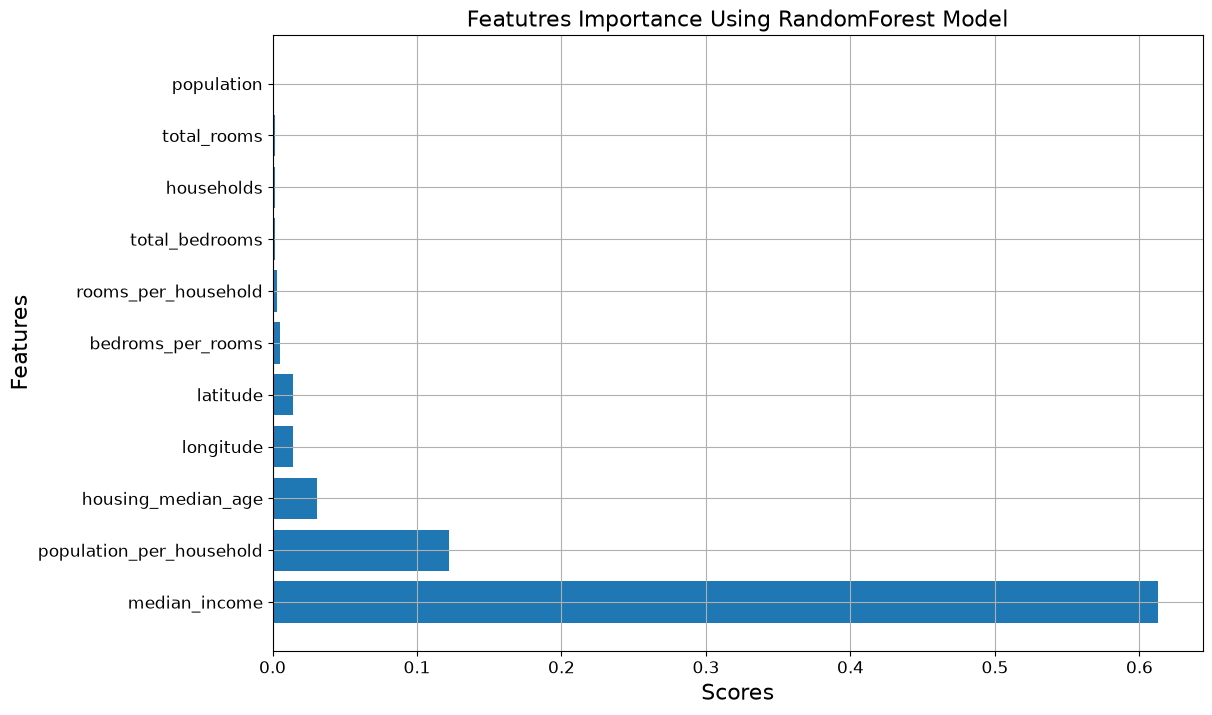

In [40]:
## to DF and then plotting
df_feat_import_forest = pd.DataFrame({"Features": keys_forest, "Scores": values_forest})
df_feat_import_forest = df_feat_import_forest.sort_values(by="Scores", ascending=False)

## plotting
plt.figure(figsize=(12, 8))
plt.barh(y=df_feat_import_forest["Features"], width=df_feat_import_forest["Scores"])
plt.title("Featutres Importance Using RandomForest Model", fontsize=16, c="k")
plt.xlabel("Scores", fontsize=16, c="k")
plt.ylabel("Features", fontsize=16, c="k")
plt.xticks(c="k", fontsize=12)
plt.yticks(c="k", fontsize=12)
plt.grid("on")
plt.show()

* > ### `XGboost Model`

In [53]:
## Using the Hero API -- XGBOOST
xgb_reg = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=0.8, random_state=42)
xgb_reg.fit(X_train_final, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [54]:
y_pred_train_xgb = xgb_reg.predict(X_train_final)
root_mean_squared_error(y_train, y_pred_train_xgb)

37064.40886541899

In [55]:
## Get Prediction using (cross_val_predict)
y_pred_xgb = cross_val_predict(
    estimator=xgb_reg, X=X_train_final, y=y_train, cv=5, method="predict", n_jobs=-1
)
## You can check the (RMSE) using what model predicts and compare it with the Mean of above result -- almost the same
## take care of this point --> don't use .predict when you are using (crossValidation)
rmse_pred_xgb = root_mean_squared_error(y_train, y_pred_xgb) 
print(
    f"RMSE after prediction Using XGBoost --- {rmse_pred_xgb:.4f}"
)  ## almost the same result :D

RMSE after prediction Using XGBoost --- 47202.9625


### `Tuning XGBoost`

In [56]:
### Let's try tuning XGBoost using GridSearchCV  --- needs alot of tuning
params_best_xgb = {
    "n_estimators": np.arange(100, 200, 50),
    "max_depth": np.arange(4, 15, 2),
    "learning_rate": [0.1, 0.2],
    "subsample": [0.8, 0.9],
}


## Intitalize the GridSearchCV and Fit ti Data
grid_xgb = GridSearchCV(
    estimator=xgb_reg,
    param_grid=params_best_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=6,
)
grid_xgb.fit(X_train_final, y_train)  ## train

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.2], 'max_depth': array([ 4, 6..., 10, 12, 14]), 'n_estimators': array([100, 150]), 'subsample': [0.8, 0.9]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluatio

In [57]:
## Get the best Params
best_xgb_params = grid_xgb.best_params_
print("best_xgb_params -- ", best_xgb_params)

## Get the best estimator
best_xgb = grid_xgb.best_estimator_  ## predict using this Model
print("best_xgb -- ", best_xgb)

best_xgb_params --  {'learning_rate': 0.1, 'max_depth': np.int64(8), 'n_estimators': np.int64(150), 'subsample': 0.8}
best_xgb --  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=np.int64(8),
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None,
             n_estimators=np.int64(150), n_jobs=None, num_parallel_tree=None, ...)


In [58]:
y_pred_train_xgb_tuned = best_xgb.predict(X_train_final)
root_mean_squared_error(y_train, y_pred_train_xgb_tuned)

21370.56480090079

In [59]:
## Get Prediction using (cross_val_predict)
y_pred_tuned_xgb = cross_val_predict(
    estimator=best_xgb, X=X_train_final, y=y_train, cv=5, method="predict", n_jobs=-1
)
## You can check the (RMSE) using what model predicts and compare it with the Mean of above result -- almost the same
## take care of this point --> don't use .predict when you are using (crossValidation)
rmse_pred_tuned_xgb = root_mean_squared_error(y_train, y_pred_tuned_xgb) 
print(
    f"RMSE after prediction Using Tuned XGBoost --- {rmse_pred_tuned_xgb:.4f}"
)  ## almost the same result :D

RMSE after prediction Using Tuned XGBoost --- 46119.3054


### `Final Evaluation on the Held-out Test Set`
``This test set was never touched during training or tuning -- evaluate only once, here, at the very end``

In [60]:
## Evaluate the tuned models on the untouched Test Set (only used once, at the very end)
y_pred_test_forest = best_forest.predict(X_test_final)
y_pred_test_xgb = best_xgb.predict(X_test_final)

rmse_test_forest = root_mean_squared_error(y_test, y_pred_test_forest) 
rmse_test_xgb = root_mean_squared_error(y_test, y_pred_test_xgb) 

r2_test_forest = r2_score(y_test, y_pred_test_forest)
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)

print(f"RandomForest -- Test RMSE: {rmse_test_forest:.4f} | Test R2: {r2_test_forest:.4f}")
print(f"XGBoost      -- Test RMSE: {rmse_test_xgb:.4f} | Test R2: {r2_test_xgb:.4f}")

RandomForest -- Test RMSE: 61541.6586 | Test R2: 0.7110
XGBoost      -- Test RMSE: 45373.0872 | Test R2: 0.8429


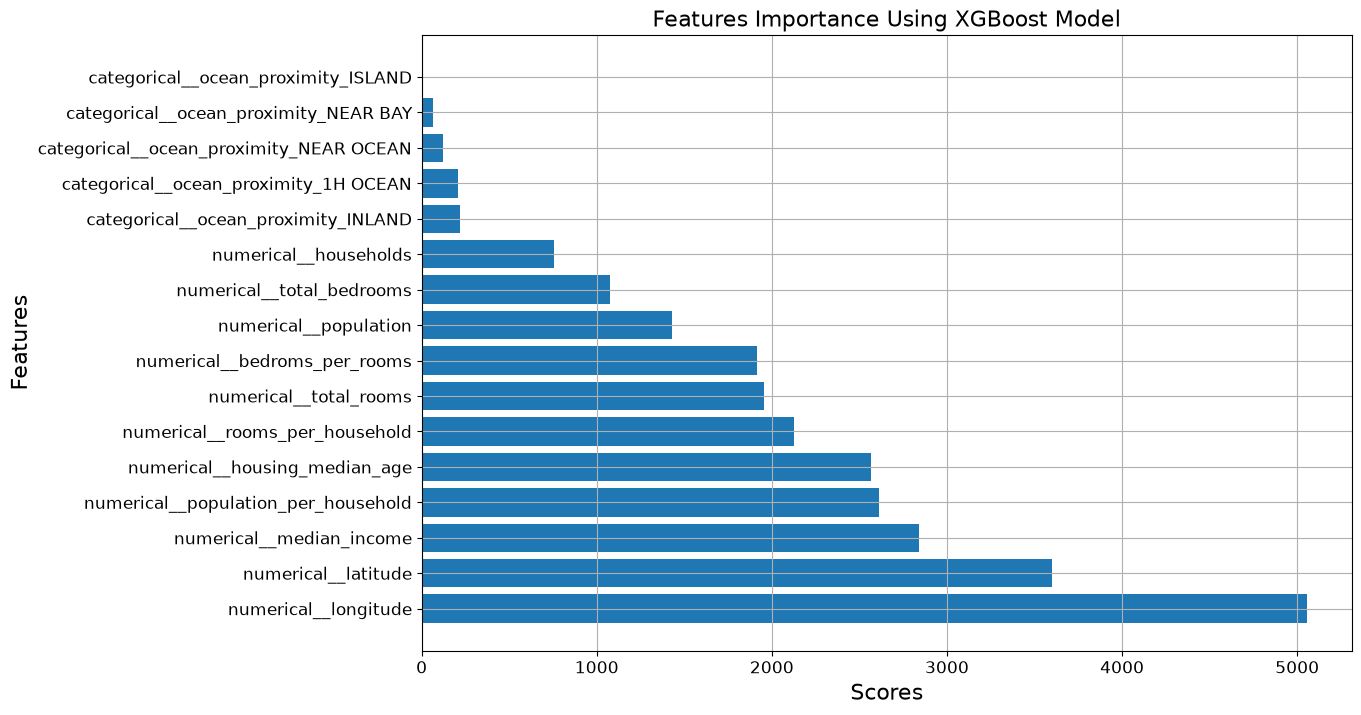

In [61]:
## Using XGBoost to get the Feature Importance
booster_scores = best_xgb.get_booster().get_score(importance_type="weight")

## Map XGBoost's internal f0, f1, ... names back to the real transformed feature names
all_feature_names = preprocessor.get_feature_names_out()
feat_import_xgb = {
    all_feature_names[int(f[1:])]: score for f, score in booster_scores.items()
}

df_feat_import_xgb = pd.DataFrame(
    list(feat_import_xgb.items()), columns=["Features", "f_scores"]
).sort_values(by="f_scores", ascending=False)

## plotting
plt.figure(figsize=(12, 8))
plt.barh(y=df_feat_import_xgb["Features"], width=df_feat_import_xgb["f_scores"])
plt.title("Features Importance Using XGBoost Model", fontsize=16, c="k")
plt.xlabel("Scores", fontsize=16, c="k")
plt.ylabel("Features", fontsize=16, c="k")
plt.xticks(c="k", fontsize=12)
plt.yticks(c="k", fontsize=12)
plt.grid("on")
plt.show()

### `Download the best Model --- best_xgb`

In [62]:
joblib.dump(best_xgb, os.path.join(MODEL_FOLDER_PATH, "best_xgb.pkl"))

['c:\\Users\\hp\\Desktop\\python projects\\house-price-predection\\notebooks\\..\\models\\best_xgb.pkl']